In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import cv2
import tifffile
from skimage.transform import resize
import tensorflow as tf
import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D, Reshape, Input, Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
import dcgan as dcgan
import wgan as wgan
import prgan as prgan
import importlib
import ppgan as ppgan

from scores import scores
from scores import preprocess_array
import os

try:
    from tensorflow.keras.optimizers import Adam
except:
    from keras.optimizers import Adam

In [2]:
NOISE_DIM = 100 
BATCH_SIZE = 20
EPOCHS = 100
STEPS = 5
SEED = 40
WIDTH, HEIGHT, CHANNELS = 128, 128, 5
OPTIMIZER = Adam(0.0002, 0.5)

In [3]:
MAIN_DIR = r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\LARGO1\08-30"

# Find the last occurrence of the backslash (\)
last_backslash_index = MAIN_DIR.rfind('\\')
# Extract the substring starting from the last backslash
DATE = MAIN_DIR[last_backslash_index + 1:]

SYNTHETIC_PATH = r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Repos\plant-disease-prediction\dataset\synthetic"

In [4]:
def load_images(folder):
    imgs = []
    target = 1
    labels = []
    for i in os.listdir(folder):
        if i.endswith("_UNHEALTHY.tif"):
            img_dir = os.path.join(folder,i)
            try:
                img = tifffile.imread(img_dir)
                # Extract the first 3 channels (RGB)
                img = img[:,:,:]
                
                img = cv2.resize(img, (128,128))
                import sys
                import numpy
                numpy.set_printoptions(threshold=sys.maxsize)
                img = (img / 256).astype(np.uint8)                
                imgs.append(img)
                labels.append(target)
            except:
                continue
                
    imgs = np.array(imgs)
    labels = np.array(labels)

    return imgs, labels

In [5]:
data, labels = load_images(MAIN_DIR)
print(data.shape)

(26, 128, 128, 5)


In [6]:
np.random.seed(SEED)
idxs = np.random.randint(0, data.shape[0], 20)
print(idxs)
X_train = data[idxs]

[ 6  7  5 24 24 18  1 12  7 18 19 10 23 19  9  0 17 21  9  8]


0


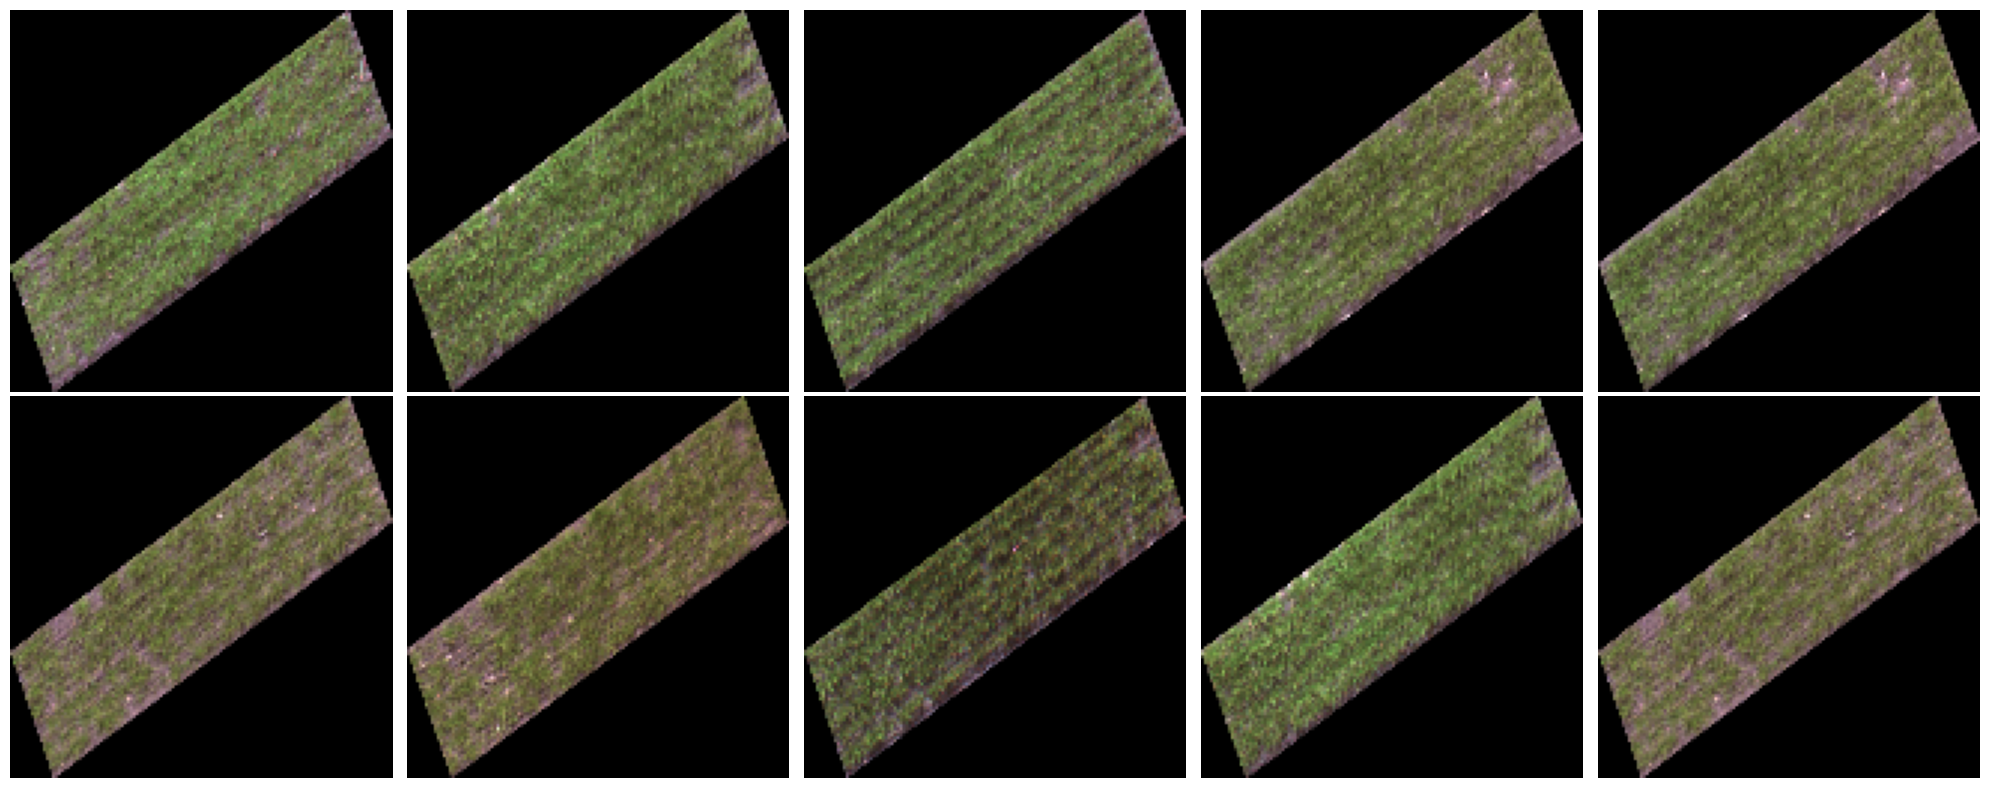

In [7]:

plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()
X_train.shape
print(np.amin(X_train))

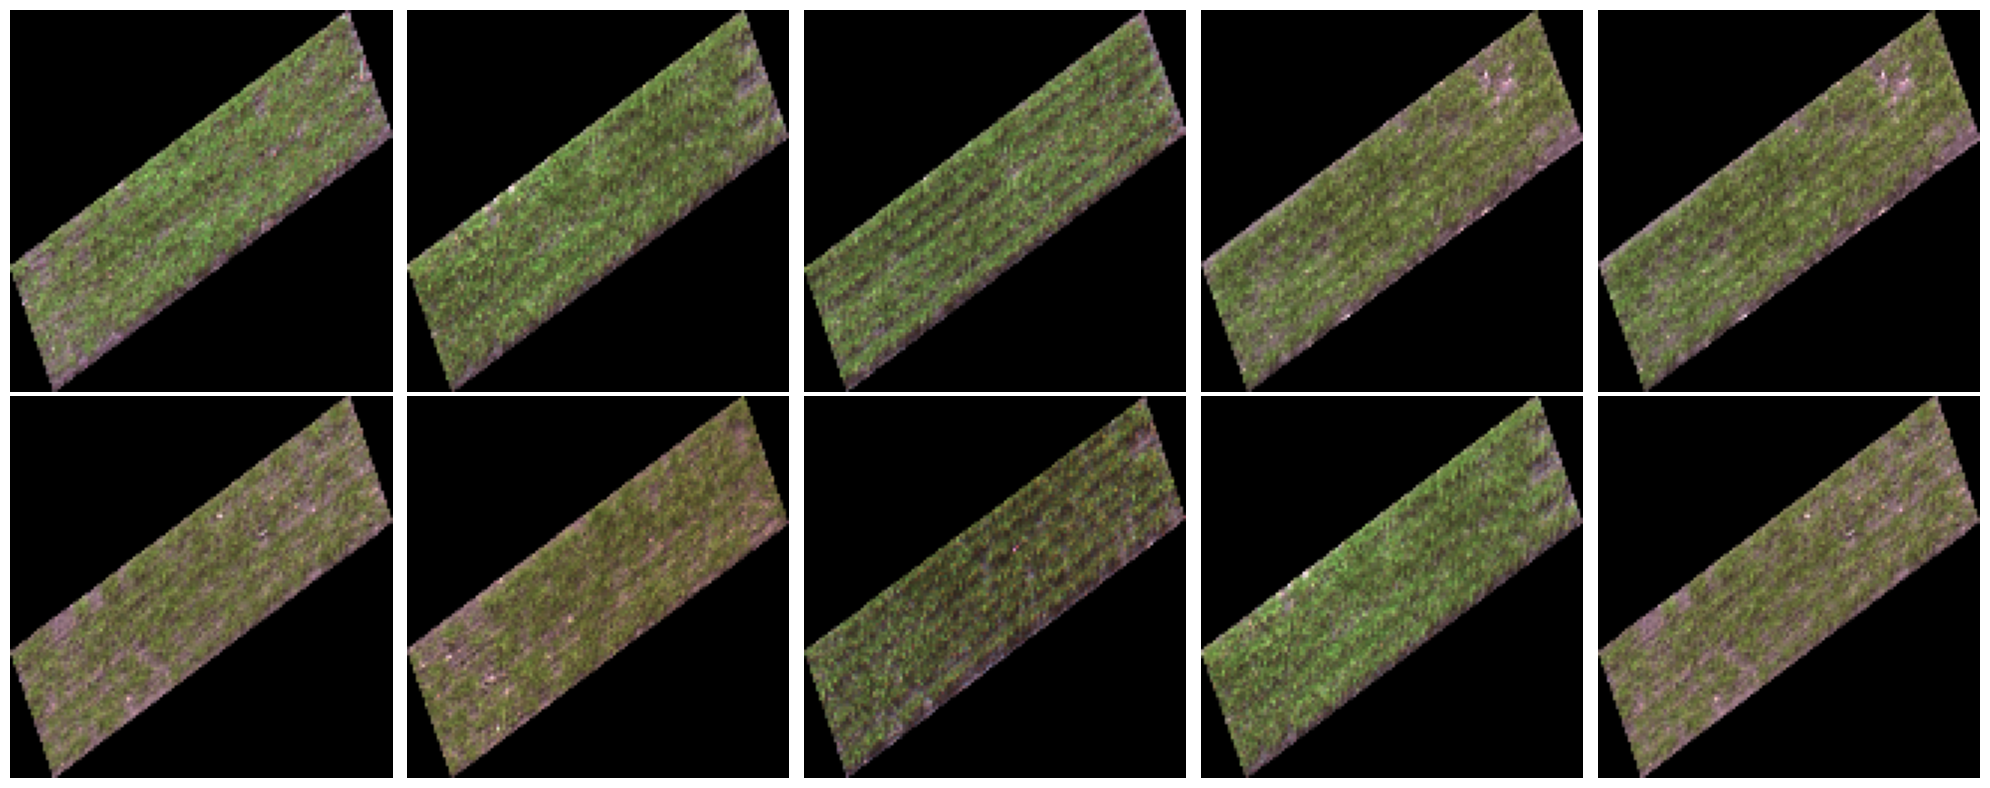

In [8]:
# Normalize the Images
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())

# Reshape images 
X_train = X_train.reshape(-1, WIDTH,HEIGHT,CHANNELS)

# Check shape
X_train.shape

plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()

In [9]:
import importlib 
importlib.reload(ppgan)
importlib.reload(dcgan)
importlib.reload(wgan)
noise = np.random.normal(0,1, size=(BATCH_SIZE, NOISE_DIM))
noise_wgan = tf.random.normal([BATCH_SIZE, NOISE_DIM])


In [10]:
print('DCGAN TRAINING STARTED...')

DCGAN TRAINING STARTED...


In [11]:
generator_dcgan, discriminator_dcgan, dcgan_model = dcgan.build(Adam(0.0002, 0.5), NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
generator_dcgan, generator_dcgan_loss_values = dcgan.train(X_train, generator_dcgan, discriminator_dcgan, dcgan_model, noise, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)

'EPOCH: 100 Generator Loss: 1.5893 Discriminator Loss: 0.5425'

In [12]:
print('PPGAN TRAINING STARTED...')

PPGAN TRAINING STARTED...


In [13]:
generator_ppgan, discriminator_ppgan1, discriminator_ppgan2, ppgan_model = ppgan.build(Adam(0.0002, 0.5), NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
generator_ppgan, generator_ppgan_loss_values = ppgan.train(X_train, generator_ppgan, discriminator_ppgan1, discriminator_ppgan2, ppgan_model, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)

'EPOCH: 100 Generator Loss: 0.9968 Discriminator 1 Loss: 1.9520 Discriminator 2 Loss: 1.9987'

In [14]:

generator_wgan, generator_wgan_loss_values = wgan.train(X_train, WIDTH, HEIGHT, CHANNELS, NOISE_DIM, Adam(0.0002, 0.5), EPOCHS, STEPS, BATCH_SIZE)

'Epoch 100/100, Generator Loss: 4.7335, Discriminator Loss: -21.5995'

In [15]:
#!pip install .\GDAL-3.3.3-cp310-cp310-win_amd64.whl

1/1 [==============================] - 0s 373ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

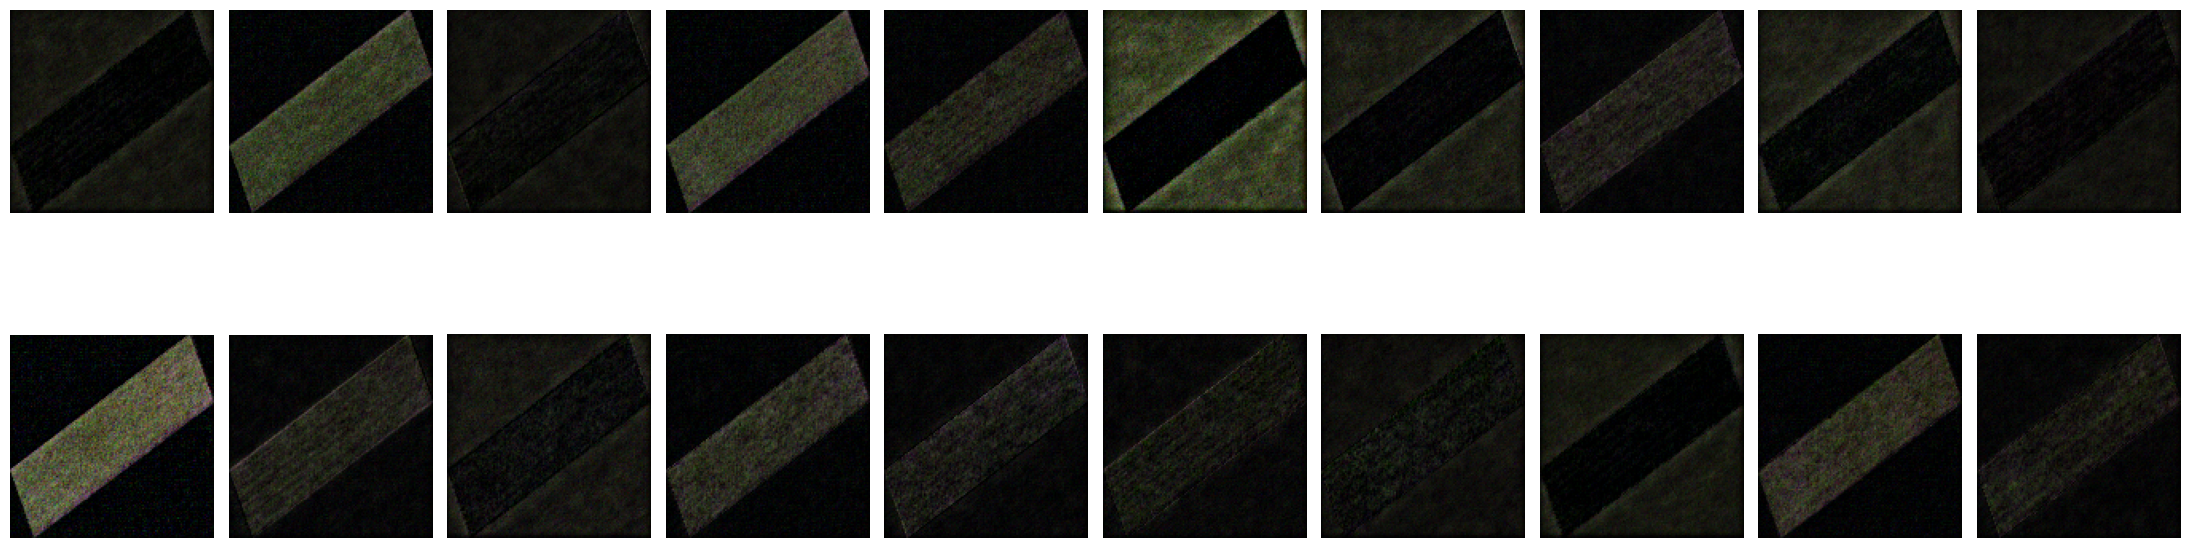

1/1 [==============================] - 0s 392ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

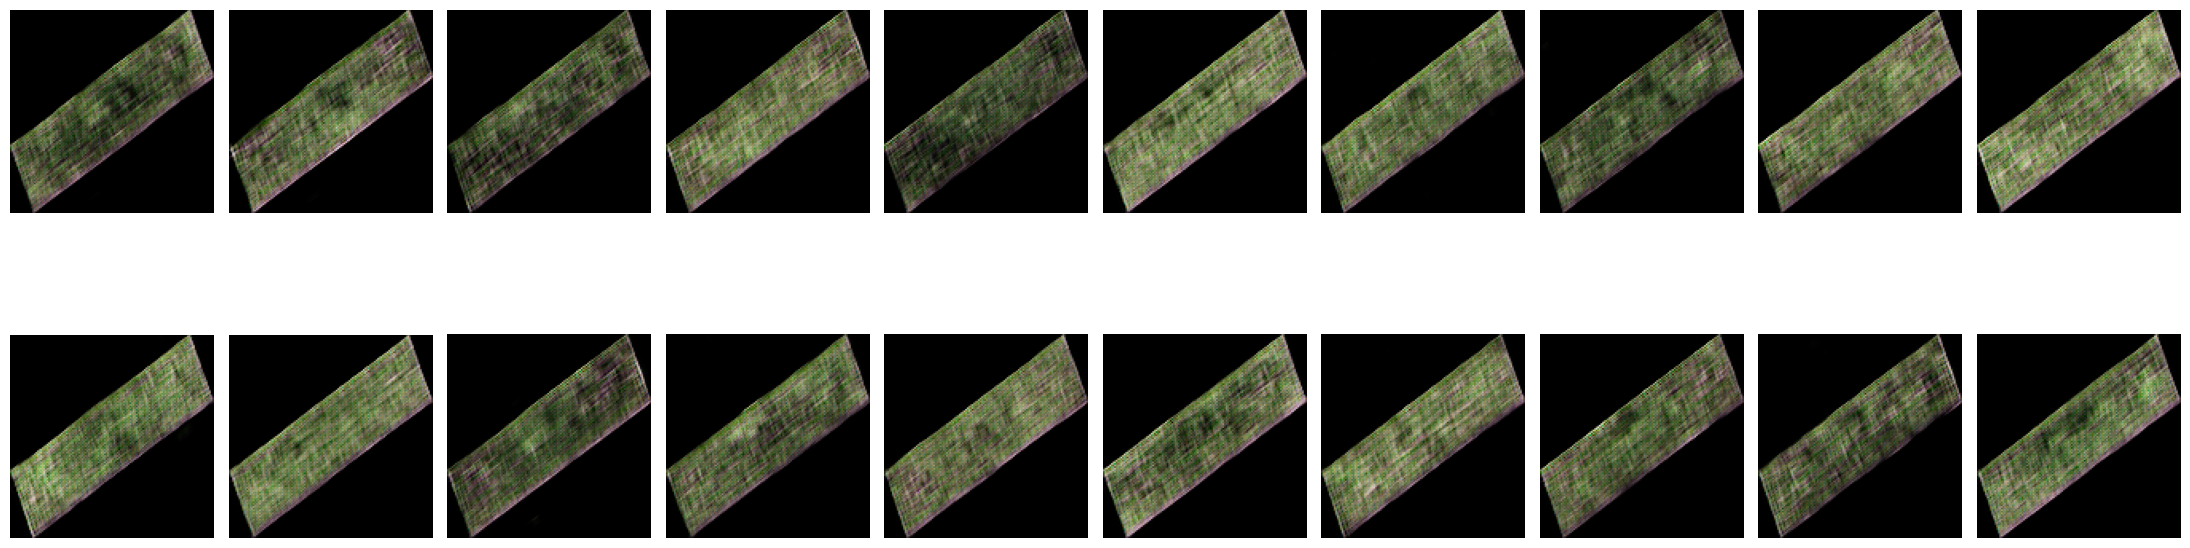

1/1 [==============================] - 0s 447ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

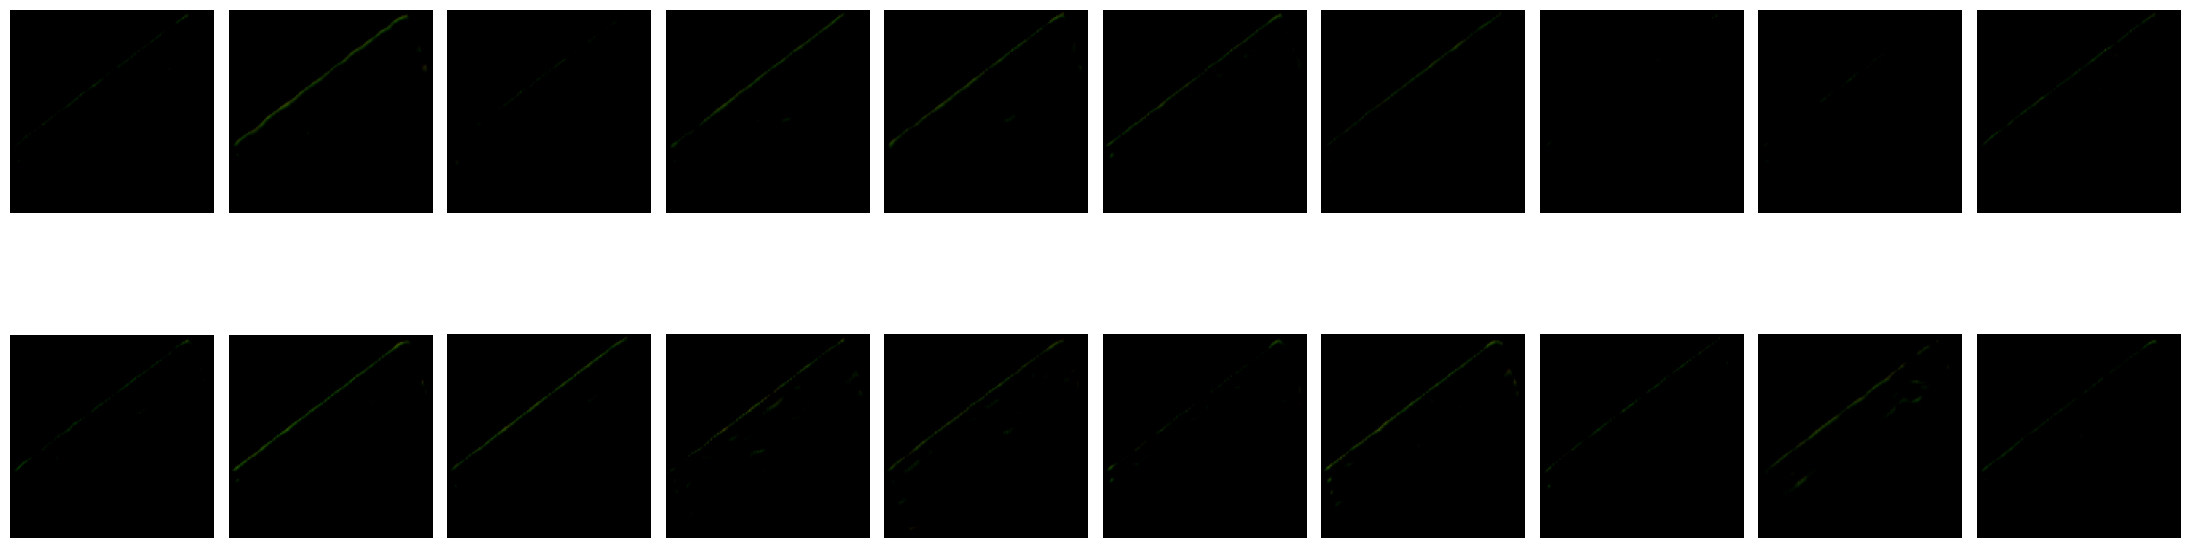

In [16]:
import utils
importlib.reload(utils)
noise = np.random.normal(0, 1, size=(BATCH_SIZE, NOISE_DIM))
samples_ppgan = utils.sample_images(generator_ppgan, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix=DATE, sufix='PPGAN', path=SYNTHETIC_PATH, save=True)
samples_dcgan = utils.sample_images(generator_dcgan, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix=DATE, sufix='DCGAN', path=SYNTHETIC_PATH, save=True)
samples_wgan = utils.sample_images(generator_wgan, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix=DATE, sufix='WGAN', path=SYNTHETIC_PATH, save=True)

In [69]:
import scores
importlib.reload(scores) 
from scores import scores, preprocess_array

samples_dcgan_array = np.array(samples_dcgan)
samples_ppgan_array = np.array(samples_ppgan)
samples_wgan_array = np.array(samples_wgan)
#samples_prgan_array = np.array(samples_prgan)

X_train_array = np.array(X_train)

samples_dcgan_array = preprocess_array(samples_dcgan_array)
samples_ppgan_array = preprocess_array(samples_ppgan_array)
samples_wgan_array = preprocess_array(samples_wgan_array)
#samples_prgan_array = preprocess_array(samples_prgan_array)

X_train_array = preprocess_array(X_train_array)

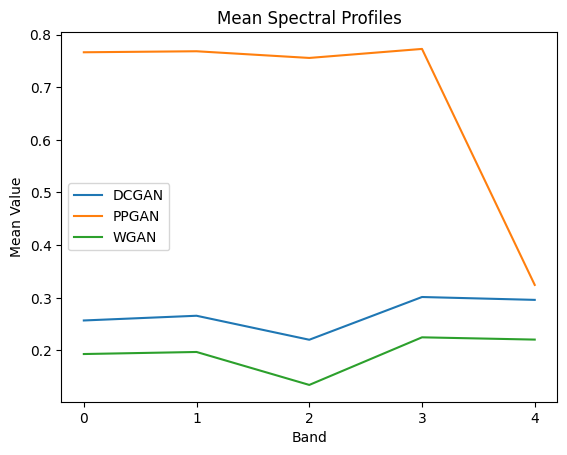

In [72]:
# Calculate the mean spectral profiles for each data array
mean_real_images = np.mean(X_train_array, axis=(0, 1, 2))
mean_dcgan = np.mean(samples_dcgan_array, axis=(0, 1, 2))
mean_ppgan = np.mean(samples_ppgan_array, axis=(0, 1, 2))
mean_wgan = np.mean(samples_wgan_array, axis=(0, 1, 2))

# Plot multiple lines on the same chart
bands = range(5)
plt.plot(bands, mean_dcgan, label='DCGAN')
plt.plot(bands, mean_ppgan, label='PPGAN')
plt.plot(bands, mean_wgan, label='WGAN')

plt.xlabel('Band')
plt.ylabel('Mean Value')
plt.title('Mean Spectral Profiles')
plt.xticks(bands)
plt.legend()
plt.show()

In [18]:
import scores
importlib.reload(scores) 
from scores import scores
print(samples_dcgan_array.shape)

flatten_real_images = X_train[:BATCH_SIZE].flatten()
flatten_dcgan_generated_images = samples_dcgan_array[:BATCH_SIZE].flatten()
flatten_ppgan_generated_images = samples_ppgan_array[:BATCH_SIZE].flatten()
flatten_wgan_generated_images = samples_wgan_array[:BATCH_SIZE].flatten()
dcgan_fid, dcgan_fid_error, dcgan_bc, dcgan_bc_error, dcgan_cs, dcgan_cs_error, dcgan_corr, dcgan_corr_error, dcgan_inter, dcgan_inter_error = scores(X_train[:BATCH_SIZE], samples_dcgan_array[:BATCH_SIZE], flatten_real_images, flatten_dcgan_generated_images)
ppgan_fid, ppgan_fid_error, ppgan_bc, ppgan_bc_error, ppgan_cs, ppgan_cs_error, ppgan_corr, ppgan_corr_error, ppgan_inter, ppgan_inter_error = scores(X_train[:BATCH_SIZE], samples_ppgan_array[:BATCH_SIZE], flatten_real_images, flatten_ppgan_generated_images)

#prgan_fid, prgan_fid_error, prgan_bc, prgan_bc_error, prgan_cs, prgan_cs_error, prgan_corr, prgan_corr_error, prgan_inter, prgan_inter_error = scores(X_train_array[:30], samples_prgan_array[:30])

(20, 128, 128, 5)
1/1 [==============================] - 0s 154ms/step
Bhattacharyya started...
Bhattacharyya done.
Chi-square done.
Correlation started...
Correlation done.
Done!
1/1 [==============================] - 0s 161ms/step
Bhattacharyya started...
Bhattacharyya done.
Chi-square done.
Correlation started...
Correlation done.
Done!


In [19]:
wgan_fid, wgan_fid_error, wgan_bc, wgan_bc_error, wgan_cs, wgan_cs_error, wgan_corr, wgan_corr_error, wgan_inter, wgan_inter_error = scores(X_train[:BATCH_SIZE], samples_wgan_array[:BATCH_SIZE], flatten_real_images, flatten_wgan_generated_images)

1/1 [==============================] - 0s 163ms/step
Bhattacharyya started...
Bhattacharyya done.
Chi-square done.
Correlation started...
Correlation done.
Done!


In [36]:
baseline_images = np.flip(X_train_array, axis=0)
flipped_images = np.empty_like(X_train_array)
for i in range(len(X_train_array)):
    image = X_train_array[i]
    flipped_image = np.flip(image, axis=1)  # Flip the image horizontally
    flipped_images[i] = flipped_image
flatten_baseline_images = baseline_images[:BATCH_SIZE].flatten()
flatten_flipped_images = flipped_images[:BATCH_SIZE].flatten()

In [37]:
flipped_images_fid, flipped_images_fid_error, flipped_images_bc, flipped_images_bc_error, flipped_images_cs, flipped_images_cs_error, flipped_images_corr, flipped_images_corr_error, flipped_images_inter, flipped_images_inter_error = scores(X_train[:BATCH_SIZE], flipped_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)
baseline_fid, baseline_fid_error, baseline_bc, baseline_bc_error, baseline_cs, baseline_cs_error, baseline_corr, baseline_corr_error, baseline_inter, baseline_inter_error = scores(X_train[:BATCH_SIZE], baseline_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)



1/1 [==============================] - 0s 164ms/step
Bhattacharyya started...
Bhattacharyya done.
Chi-square done.
Correlation started...
Correlation done.
Done!
1/1 [==============================] - 0s 174ms/step
Bhattacharyya started...
Bhattacharyya done.
Chi-square done.
Correlation started...
Correlation done.
Done!


[0.12122929831503472, 0.691088595276932, 0.012438725293180864, 0.0418950687842665]
[0.4474705503398097, 0.593597077679881, 0.5571782520800509, 0.5619488509714081]
[7.785402859998818, 6.615100269196336, 8.1977606533892, 6.987131595202079]
[-1.178065892822833e-05, -1.7699546426966437e-05, 1.613501047116408e-06, 4.7136596059215376e-05]
[0.0022152878496665106, 0.022682082011323986, 0.07314610819282402, 0.012988429068047837]


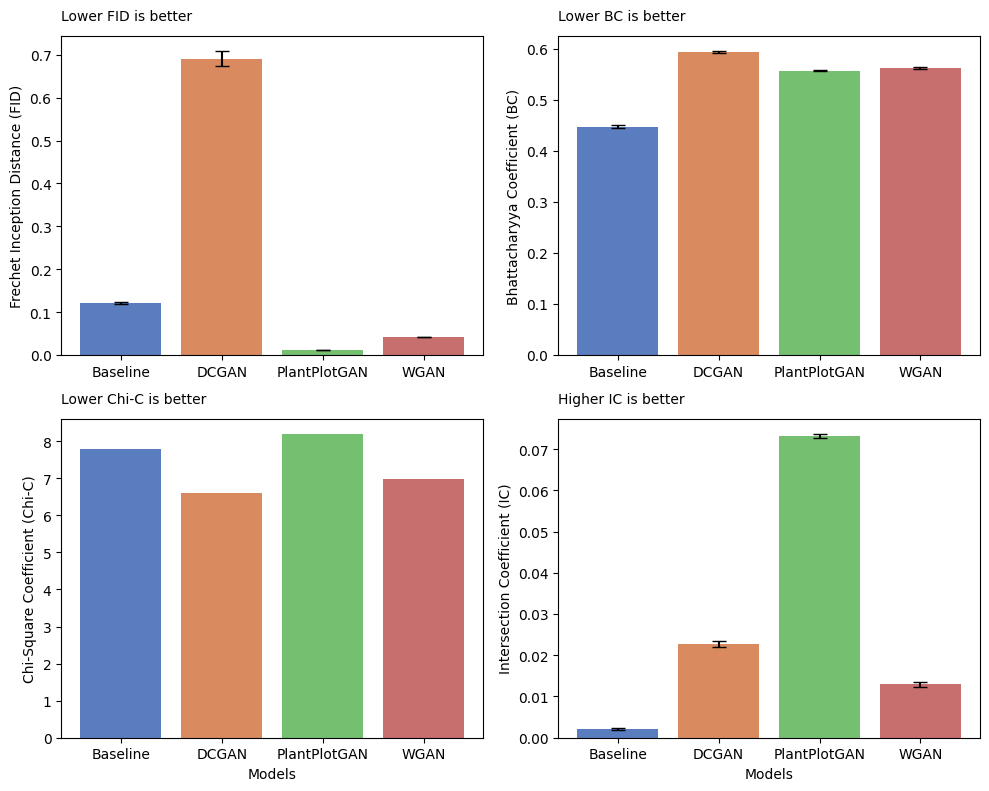

In [57]:
import seaborn as sns
# Data for FID comparison
model_names = ['Baseline', 'DCGAN', 'PlantPlotGAN', 'WGAN']
fid_means = [baseline_fid/50000000, dcgan_fid/10000, ppgan_fid/5000, wgan_fid/1000]
fid_errors = [baseline_fid_error/50000000, dcgan_fid_error/10000, ppgan_fid_error/5000, wgan_fid_error/1000]
print(fid_means)

bc_means = [baseline_bc, dcgan_bc, ppgan_bc, wgan_bc]
bc_errors = [baseline_bc_error, dcgan_bc_error, ppgan_bc_error, wgan_bc_error]
print(bc_means)

cs_means = [baseline_cs/100000, dcgan_cs/100000, ppgan_cs/100000, wgan_cs/100000]
cs_errors = [baseline_cs_error/100000, dcgan_cs_error/100000, ppgan_cs_error/100000, wgan_cs_error/100000]
print(cs_means)

corr_means = [baseline_corr, dcgan_corr, ppgan_corr, wgan_corr]
corr_errors = [baseline_corr_error, dcgan_corr_error, ppgan_bc_error, wgan_bc_error]
print(corr_means)

inter_means = [baseline_inter, dcgan_inter, ppgan_inter, wgan_inter]
inter_errors = [baseline_inter_error, dcgan_inter_error, ppgan_inter_error, wgan_inter_error]
print(inter_means)

# Create a figure with five subplots
# fig, ((ax1, ax2), (ax3, ax4), (ax5, _)) = plt.subplots(3, 2, figsize=(12, 15))
fig, ((ax1, ax2), (ax3, ax5)) = plt.subplots(2, 2, figsize=(10, 8))

# # Plotting the FID comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=fid_means, marker='o', color='red', ax=ax1)
# ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
# ax1.set_xlabel('Models')
# ax1.set_ylabel('Frechet Inception Distance (FID)')
# #ax1.set_title('FID Comparison between Models')

# # Plotting the BC comparison using a line chart with error bars
# sns.barplot(x=model_names, y=bc_means, marker='o', color='red', ax=ax2)
# ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
# ax2.set_xlabel('Models')
# ax2.set_ylabel('Bhattacharyya Coefficient (BC)')
# #ax2.set_title('BC Comparison between Models')

# # Plotting the Chi-Square comparison using a line chart with error bars
# sns.barplot(x=model_names, y=cs_means, marker='o', color='red', ax=ax3)
# ax3.errorbar(x=model_names, y=cs_means, yerr=cs_errors, fmt='none', color='black', capsize=5)
# ax3.set_xlabel('Models')
# ax3.set_ylabel('Chi-Square Coefficient (Chi-C)')
# #ax3.set_title('Chi-C Comparison between Models')

# # Plotting the Correlation comparison using a line chart with error bars
# # sns.lineplot(x=model_names, y=corr_means, marker='o', color='red', ax=ax4)
# # ax4.errorbar(x=model_names, y=corr_means, yerr=corr_errors, fmt='none', color='black', capsize=5)
# # ax4.set_xlabel('Models')
# # ax4.set_ylabel('Correlation Coefficient (CC)')
# # ax4.set_title('CC Comparison between Models')

# # Plotting the Intersection comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=inter_means, marker='o', color='red', ax=ax5)
# ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
# ax5.set_xlabel('Models')
# ax5.set_ylabel('Intersection Coefficient (IC)')
# #ax5.set_title('IC Comparison between Models')

# Plotting the FID comparison using a bar chart with error bars
sns.barplot(x=model_names, y=fid_means, palette='muted', ax=ax1)
ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
ax1.set_ylabel('Frechet Inception Distance (FID)')
ax1.text(0, 1.05, 'Lower FID is better', transform=ax1.transAxes)

# Plotting the BC comparison using a bar chart with error bars
sns.barplot(x=model_names, y=bc_means, palette='muted', ax=ax2)
ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
ax2.set_ylabel('Bhattacharyya Coefficient (BC)')
ax2.text(0, 1.05, 'Lower BC is better', transform=ax2.transAxes)

# Plotting the Chi-Square comparison using a bar chart with error bars
sns.barplot(x=model_names, y=cs_means, palette='muted', ax=ax3)
ax3.errorbar(x=model_names, y=cs_means, fmt='none', color='black', capsize=5)
ax3.set_xlabel('Models')
ax3.set_ylabel('Chi-Square Coefficient (Chi-C)')
ax3.text(0, 1.05, 'Lower Chi-C is better', transform=ax3.transAxes)

# Plotting the Intersection comparison using a bar chart with error bars
sns.barplot(x=model_names, y=inter_means, palette='muted', ax=ax5)
ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
ax5.set_xlabel('Models')
ax5.set_ylabel('Intersection Coefficient (IC)')
ax5.text(0, 1.05, 'Higher IC is better', transform=ax5.transAxes)

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plot
plt.show()